# Notebook 4 - Modelado y segmentacion territorial

Este cuaderno desarrolla la fase de modelado del pilar de Analisis del Dato a partir de la tabla municipal agregada generada en el `Notebook 3`.

A diferencia del cuaderno anterior, centrado en el analisis descriptivo y la construccion de indicadores, aqui el objetivo es identificar grupos de municipios con perfiles climaticos, territoriales, sociales y de exposicion fisica similares mediante tecnicas de segmentacion no supervisada.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_analisis_municipal.csv`

El enfoque adoptado en esta fase no pretende todavia predecir siniestros reales, sino detectar patrones municipales de riesgo relativo, intensidad climatica, vulnerabilidad territorial y exposicion construida que puedan resultar utiles para la interpretacion posterior y para el Analisis de Negocio.

## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El notebook parte de la salida analitica municipal ya construida, por lo que no repite el proceso ETL ni el analisis exploratorio anterior.

Ademas, se preparan las rutas para posibles salidas de modelado, visualizacion y exportacion de resultados.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"

ANALYTIC_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_analisis_municipal.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"
SEGMENTED_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_segmentado.csv"

MODEL_OUT = OUT / "modelado"
MODEL_OUT.mkdir(parents=True, exist_ok=True)
MAPS.mkdir(parents=True, exist_ok=True)

print("Dataset municipal analitico:", ANALYTIC_MUNICIPAL_FILE)
print("Existe:", ANALYTIC_MUNICIPAL_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Directorio de salida:", MODEL_OUT)
print("Salida segmentada prevista:", SEGMENTED_MUNICIPAL_FILE)

Dataset municipal analitico: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_analisis_municipal.csv
Existe: True
Geometria municipal disponible: True
Directorio de salida: C:\Users\gonza\OneDrive\tfg\output\modelado
Salida segmentada prevista: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv


## 1. Objetivo analitico del modelado y carga de la base municipal

El objetivo de esta fase es identificar grupos de municipios con perfiles climaticos y territoriales similares a partir de la tabla agregada construida en el `Notebook 3`. Dado que no se dispone de datos reales de siniestralidad para entrenar un modelo supervisado, el enfoque adoptado se basa en tecnicas de segmentacion no supervisada.

En consecuencia, el modelado no pretende predecir siniestros, sino detectar patrones municipales de riesgo relativo, intensidad climatica y vulnerabilidad territorial. Esta aproximacion permite comparar municipios, construir tipologias y preparar una lectura posterior orientada a negocio.

Antes de seleccionar variables y entrenar modelos, se carga la base municipal analitica y se comprueba que conserva la estructura esperada.


In [2]:
df_mun = pd.read_csv(ANALYTIC_MUNICIPAL_FILE)

print("Shape:", df_mun.shape)
print("Municipios unicos:", df_mun["municipio"].nunique())
print("Columnas:", len(df_mun.columns))
print("Duplicados municipales:", df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())

assert df_mun["municipio"].nunique() == 542, "La base analitica debe conservar 542 municipios."
assert df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "Hay duplicados municipales."

key_cols = [
    "municipio",
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "dias_suelo_seco",
    "dias_radiacion_alta",
    "dias_runoff_extremo",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "densidad_edificios_km2",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
    "altitud_m",
    "score_riesgo_exploratorio",
]

print("Columnas principales disponibles:")
print([col for col in key_cols if col in df_mun.columns])

display(df_mun[[col for col in key_cols if col in df_mun.columns]].head())

Shape: (542, 80)
Municipios unicos: 542
Columnas: 80
Duplicados municipales: 0
Columnas principales disponibles:
['municipio', 'precip_p99', 'dias_precip_extrema', 'temp_p95', 'dias_calor_intenso', 'viento_p95', 'dias_suelo_seco', 'dias_radiacion_alta', 'dias_runoff_extremo', 'densidad_poblacion', 'mayores_65_pct', 'renta_media_hogar', 'densidad_edificios_km2', 'densidad_viviendas_catastro_km2', 'ratio_huella_edificada_pct', 'altitud_m', 'score_riesgo_exploratorio']


,municipio,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m,score_riesgo_exploratorio
0,Ademuz,18.368174,6,32.069465,60,6.782720,0,250,88,10.12,26.80,27809.0,20.51,14.38,0.1728,907.0,0.244267
1,Ador,37.833611,38,31.999384,68,7.682318,537,225,145,126.84,20.42,31572.0,65.19,70.97,1.0499,79.0,0.366637
2,Agost,18.520694,11,32.961835,97,7.184352,1505,284,62,78.39,20.27,30407.0,35.77,43.79,0.8237,181.0,0.302003
3,Agres,31.017301,28,34.419501,176,5.725050,0,244,114,24.10,24.80,31440.0,25.65,23.64,0.4122,756.0,0.311068
4,Agullent,28.305807,25,34.757147,200,5.912659,84,244,123,150.09,21.43,31085.0,78.74,72.46,2.7882,556.0,0.313503


## 2. Seleccion de variables para la segmentacion

La segmentacion se construye a partir de variables observables, no de los scores compuestos generados en el `Notebook 3`. Esto evita que el modelo agrupe municipios a partir de una puntuacion ya calculada de forma heuristica y permite que los clusters se expliquen desde dimensiones mas directas: peligro climatico base, contexto climatico extendido, vulnerabilidad social, exposicion fisica y condicion territorial.

La seleccion mantiene un equilibrio entre riqueza analitica e interpretabilidad. Se incorporan las nuevas variables de `ERA5-Land` extendido y Catastro, pero no se incluyen todas las columnas disponibles para no sobredimensionar el modelo ni introducir redundancia excesiva.

,bloque,variable
0,peligro_climatico_base,precip_p99
1,peligro_climatico_base,dias_precip_extrema
2,peligro_climatico_base,temp_p95
3,peligro_climatico_base,dias_calor_intenso
4,peligro_climatico_base,viento_p95
5,contexto_climatico_extendido,dias_suelo_seco
6,contexto_climatico_extendido,dias_radiacion_alta
7,contexto_climatico_extendido,dias_runoff_extremo
8,contexto_climatico_extendido,humedad_suelo_media_periodo
9,vulnerabilidad_social,densidad_poblacion


Variables seleccionadas para segmentacion: 16
- precip_p99
- dias_precip_extrema
- temp_p95
- dias_calor_intenso
- viento_p95
- dias_suelo_seco
- dias_radiacion_alta
- dias_runoff_extremo
- humedad_suelo_media_periodo
- densidad_poblacion
- mayores_65_pct
- renta_media_hogar
- densidad_edificios_km2
- densidad_viviendas_catastro_km2
- ratio_huella_edificada_pct
- altitud_m


,count,mean,std,min,25%,50%,75%,max
precip_p99,542.0,26.927875,5.382713,16.445655,23.357834,26.765683,29.846917,40.481348
dias_precip_extrema,542.0,21.920664,8.175929,5.000000,16.000000,21.000000,28.000000,41.000000
temp_p95,542.0,32.880859,1.551139,28.335553,31.729986,32.938959,34.163996,36.000543
dias_calor_intenso,542.0,109.605166,71.350680,3.000000,50.000000,101.000000,164.000000,306.000000
viento_p95,542.0,6.972567,0.719757,5.408023,6.516475,6.907734,7.409866,9.511220
dias_suelo_seco,542.0,219.201107,353.033904,0.000000,0.000000,0.000000,373.000000,1582.000000
dias_radiacion_alta,542.0,219.206642,34.235481,152.000000,194.000000,221.000000,240.000000,301.000000
dias_runoff_extremo,542.0,109.605166,32.764874,40.000000,90.250000,108.000000,123.000000,250.000000
humedad_suelo_media_periodo,542.0,0.238132,0.038816,0.108358,0.223183,0.236090,0.251813,0.336209
densidad_poblacion,542.0,580.056642,2055.248495,0.680000,15.990000,87.810000,397.387500,24305.560000


Correlaciones entre variables seleccionadas:


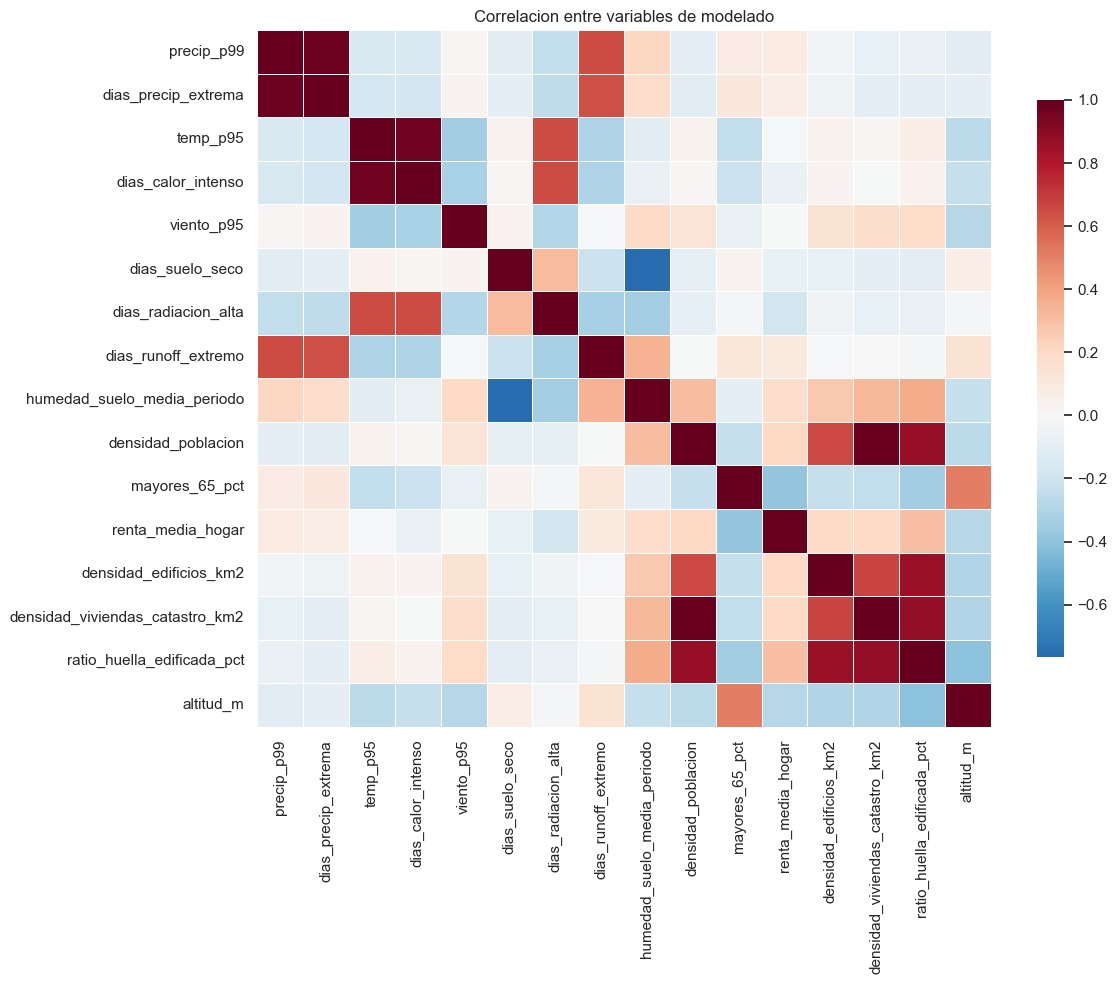

In [3]:
feature_groups = {
    "peligro_climatico_base": [
        "precip_p99",
        "dias_precip_extrema",
        "temp_p95",
        "dias_calor_intenso",
        "viento_p95",
    ],
    "contexto_climatico_extendido": [
        "dias_suelo_seco",
        "dias_radiacion_alta",
        "dias_runoff_extremo",
        "humedad_suelo_media_periodo",
    ],
    "vulnerabilidad_social": [
        "densidad_poblacion",
        "mayores_65_pct",
        "renta_media_hogar",
    ],
    "exposicion_fisica_catastro": [
        "densidad_edificios_km2",
        "densidad_viviendas_catastro_km2",
        "ratio_huella_edificada_pct",
    ],
    "condicion_fisica": [
        "altitud_m",
    ],
}

model_features = [col for cols in feature_groups.values() for col in cols]
missing_features = [col for col in model_features if col not in df_mun.columns]
if missing_features:
    raise ValueError(f"Faltan variables necesarias para el modelado: {missing_features}")

feature_catalog = []
for group, cols in feature_groups.items():
    for col in cols:
        feature_catalog.append({"bloque": group, "variable": col})

feature_catalog = pd.DataFrame(feature_catalog)
display(feature_catalog)

print("Variables seleccionadas para segmentacion:", len(model_features))
for col in model_features:
    print("-", col)

display(df_mun[model_features].describe().T)

print("Correlaciones entre variables seleccionadas:")
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_mun[model_features].corr(numeric_only=True),
    cmap="RdBu_r",
    center=0,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlacion entre variables de modelado")
plt.tight_layout()
plt.show()

## 3. Preparacion del dataset para modelado

Antes de aplicar tecnicas de segmentacion, se prepara la matriz de variables que utilizara el modelo. Esta fase incluye la comprobacion de nulos, la imputacion simple de valores faltantes, una transformacion logaritmica en variables muy asimetricas y la estandarizacion final.

La transformacion logaritmica se aplica solo a variables territoriales y de Catastro con colas muy largas, como densidad de poblacion o densidad edificada. Con ello se evita que unos pocos municipios muy urbanos dominen artificialmente la distancia entre observaciones.

In [4]:
X_raw = df_mun[model_features].copy()

print("Shape matriz original:", X_raw.shape)
print("Nulos por variable:")
display(X_raw.isna().sum().to_frame("nulos"))

# Imputacion simple para no perder municipios en esta fase exploratoria.
X_filled = X_raw.fillna(X_raw.median(numeric_only=True))

log_transform_cols = [
    "densidad_poblacion",
    "densidad_edificios_km2",
    "densidad_viviendas_catastro_km2",
    "ratio_huella_edificada_pct",
]
log_transform_cols = [col for col in log_transform_cols if col in X_filled.columns]

X_model = X_filled.copy()
for col in log_transform_cols:
    X_model[col] = np.log1p(X_model[col].clip(lower=0))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)
X_scaled = pd.DataFrame(X_scaled, columns=model_features, index=df_mun.index)

print("Variables con transformacion log1p:", log_transform_cols)
print("Shape matriz escalada:", X_scaled.shape)
display(X_scaled.head())

Shape matriz original: (542, 16)
Nulos por variable:


,nulos
precip_p99,0
dias_precip_extrema,0
temp_p95,0
dias_calor_intenso,0
viento_p95,0
dias_suelo_seco,0
dias_radiacion_alta,0
dias_runoff_extremo,0
humedad_suelo_media_periodo,0
densidad_poblacion,0


Variables con transformacion log1p: ['densidad_poblacion', 'densidad_edificios_km2', 'densidad_viviendas_catastro_km2', 'ratio_huella_edificada_pct']
Shape matriz escalada: (542, 16)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
0,-1.591690,-1.949059,-0.523579,-0.695873,-0.264010,-0.621480,0.900288,-0.660009,0.464709,-1.077469,0.271044,-0.869622,-0.819725,-0.923212,-0.965828,1.597053
1,2.027938,1.968484,-0.568801,-0.583647,0.987008,0.901025,0.169377,1.081266,0.076188,0.177610,-0.641131,-0.043213,0.132548,0.016588,-0.276101,-0.934539
2,-1.563328,-1.336943,0.052252,-0.176828,0.294516,3.645505,1.894328,-1.454275,-3.346416,-0.067238,-0.662578,-0.299064,-0.365481,-0.272239,-0.420524,-0.622676
3,0.760435,0.744252,0.992859,0.931402,-1.734849,-0.621480,0.724870,0.134256,0.091765,-0.659052,-0.014904,-0.072202,-0.638192,-0.636187,-0.736385,1.135374
4,0.256229,0.376982,1.210736,1.268080,-1.473953,-0.383323,0.724870,0.409195,-0.290664,0.263489,-0.496727,-0.150165,0.290334,0.029068,0.482429,0.523878


### 3.1 Diagnostico visual mediante PCA

La proyeccion `PCA` no se utiliza como modelo final, sino como herramienta de diagnostico. Permite representar en dos dimensiones una matriz de variables mas amplia y comprobar si existen gradientes o agrupaciones razonables antes de aplicar los algoritmos de clustering.

,componente,varianza_explicada_pct
0,PC1,33.63
1,PC2,22.19


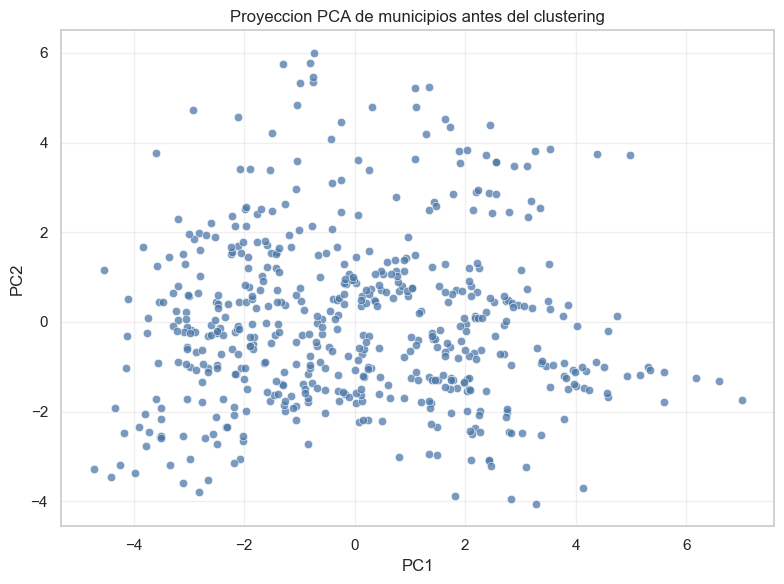

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_mun["pca_1"] = X_pca[:, 0]
df_mun["pca_2"] = X_pca[:, 1]

pca_explained = pd.DataFrame(
    {
        "componente": ["PC1", "PC2"],
        "varianza_explicada_pct": (pca.explained_variance_ratio_ * 100).round(2),
    }
)

display(pca_explained)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_mun, x="pca_1", y="pca_2", color="#4c78a8", alpha=0.75)
plt.title("Proyeccion PCA de municipios antes del clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Primer modelo: KMeans y seleccion del numero de clusters

Como primer enfoque de segmentacion se aplica `KMeans`, una tecnica no supervisada que busca agrupar observaciones en funcion de su proximidad en el espacio de variables. En este contexto, el objetivo es identificar conjuntos de municipios con perfiles climaticos, sociales y de exposicion similares.

Dado que `KMeans` requiere fijar previamente el numero de clusters, se prueban varios valores de `k` y se comparan mediante distintas metricas de adecuacion. Esta fase no persigue optimizar un unico criterio matematico de forma aislada, sino encontrar una segmentacion razonable tanto desde el punto de vista cuantitativo como interpretativo.

In [6]:
k_values = range(2, 8)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = model.fit_predict(X_scaled)

    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    kmeans_results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
            "cluster_min_size": cluster_sizes.min(),
            "cluster_max_size": cluster_sizes.max(),
        }
    )

df_kmeans_eval = pd.DataFrame(kmeans_results)
display(df_kmeans_eval)

  File "C:\Users\gonza\OneDrive\tfg\venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,cluster_min_size,cluster_max_size
0,2,6590.762034,0.221574,1.692191,170.521784,241,301
1,3,5648.022680,0.205363,1.642904,144.291540,145,239
2,4,4882.290502,0.215062,1.465831,139.201311,68,210
3,5,4480.825860,0.192945,1.600674,125.571746,61,139
4,6,4113.352930,0.212021,1.463777,118.805017,28,139
5,7,3762.272046,0.219164,1.461123,116.361622,28,141


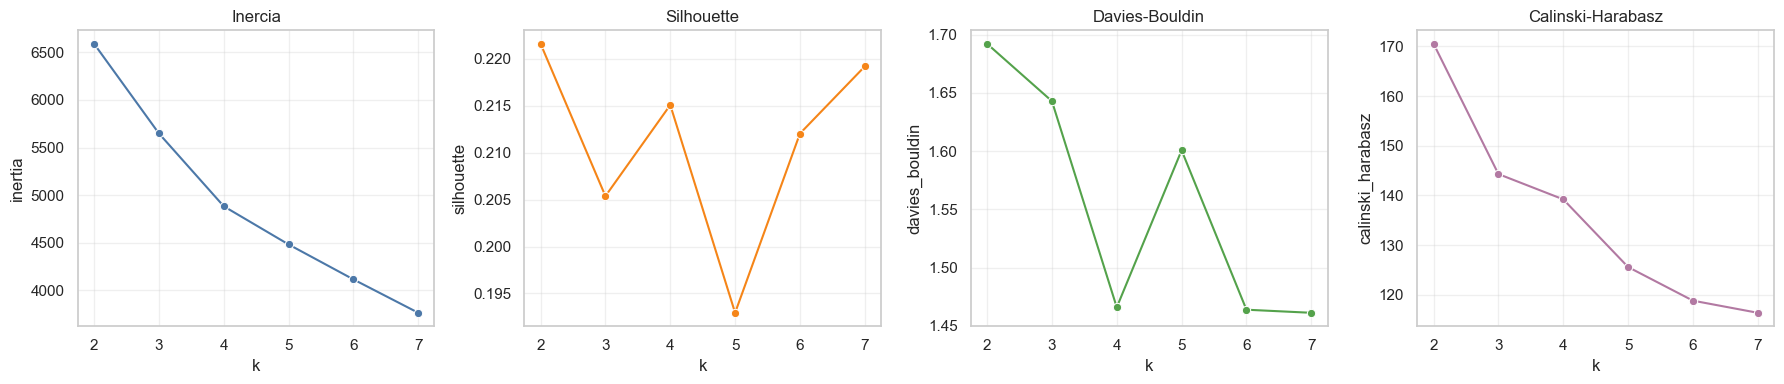

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.lineplot(data=df_kmeans_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#4c78a8")
axes[0].set_title("Inercia")

sns.lineplot(data=df_kmeans_eval, x="k", y="silhouette", marker="o", ax=axes[1], color="#f58518")
axes[1].set_title("Silhouette")

sns.lineplot(data=df_kmeans_eval, x="k", y="davies_bouldin", marker="o", ax=axes[2], color="#54a24b")
axes[2].set_title("Davies-Bouldin")

sns.lineplot(data=df_kmeans_eval, x="k", y="calinski_harabasz", marker="o", ax=axes[3], color="#b279a2")
axes[3].set_title("Calinski-Harabasz")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


La seleccion del numero de clusters se apoya en varios criterios complementarios. En general, valores altos de `silhouette` y `calinski_harabasz`, junto con valores bajos de `davies_bouldin`, sugieren una mejor separacion interna. Aun asi, en este TFG tambien importa que la solucion sea interpretable y que no genere grupos excesivamente pequenos.

Con la matriz ampliada de variables, `k=4` ofrece un equilibrio razonable entre metrica, tamano de clusters e interpretabilidad territorial. Soluciones con mas clusters capturan mas matices, pero empiezan a fragmentar el territorio en grupos demasiado reducidos para una lectura robusta en esta fase.

## 5. Ajuste final de KMeans e interpretacion de clusters

Una vez comparados varios valores posibles de `k`, se selecciona una configuracion final de `KMeans` para analizar con mayor detalle los perfiles resultantes. A partir de esta segmentacion, se asigna a cada municipio un cluster y se estudian las diferencias medias entre grupos en las variables climaticas y territoriales seleccionadas.

El objetivo de esta fase no es solo obtener una particion del dataset, sino interpretar el significado de cada cluster y valorar si la segmentacion resulta util para distinguir tipologias municipales con implicaciones analiticas y territoriales.


In [8]:
k_final = 4

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=50)
df_mun["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

print("Numero de clusters:", k_final)
print("Tamano de cada cluster:")
display(df_mun["cluster_kmeans"].value_counts().sort_index().to_frame("municipios"))

Numero de clusters: 4
Tamano de cada cluster:


,municipios
cluster_kmeans,
0,210
1,68
2,136
3,128


In [9]:
cluster_profile = (
    df_mun.groupby("cluster_kmeans")[model_features]
    .mean()
    .round(2)
)

display(cluster_profile)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,
0,26.29,21.40,31.88,65.58,6.92,177.23,202.11,114.35,0.23,25.50,29.62,30111.11,25.71,23.49,0.36,640.44
1,19.35,10.50,34.26,182.79,7.02,654.43,278.94,60.60,0.20,431.05,23.33,29664.18,108.56,248.87,2.59,329.63
2,31.47,28.40,34.18,166.95,6.54,146.76,231.40,122.60,0.24,167.11,23.19,32162.73,77.76,94.25,1.73,306.90
3,27.17,21.95,32.41,82.02,7.50,133.82,202.56,114.05,0.26,2007.80,19.83,35138.91,328.49,1022.44,8.66,76.86


In [10]:
cluster_profile_scaled = (
    df_mun.groupby("cluster_kmeans")[model_features]
    .mean()
)

cluster_profile_scaled = (
    (cluster_profile_scaled - cluster_profile_scaled.mean())
    / cluster_profile_scaled.std()
).round(2)

display(cluster_profile_scaled)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,
0,0.04,0.11,-1.07,-0.99,-0.20,-0.40,-0.74,0.40,0.03,-0.69,1.38,-0.66,-0.82,-0.70,-0.81,1.30
1,-1.34,-1.36,0.89,0.99,0.07,1.50,1.39,-1.49,-1.33,-0.25,-0.16,-0.84,-0.20,-0.21,-0.20,-0.04
2,1.08,1.06,0.82,0.72,-1.15,-0.52,0.07,0.69,0.21,-0.54,-0.20,0.16,-0.43,-0.55,-0.44,-0.14
3,0.22,0.19,-0.64,-0.72,1.28,-0.57,-0.72,0.39,1.09,1.47,-1.02,1.35,1.45,1.47,1.45,-1.13


In [11]:
display(
    df_mun[
        ["municipio", "cluster_kmeans"] + model_features
    ]
    .sort_values(["cluster_kmeans", "municipio"])
    .head(30)
)


,municipio,cluster_kmeans,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
0,Ademuz,0,18.368174,6,32.069465,60,6.782720,0,250,88,0.256154,10.12,26.80,27809.0,20.51,14.38,0.1728,907.0
14,Albalat dels Tarongers,0,22.836143,15,32.558076,83,6.689455,0,195,77,0.217291,73.71,17.51,35658.0,92.39,85.93,1.1070,535.0
17,Albocàsser,0,33.298020,32,30.702350,29,7.521599,0,171,146,0.264703,16.63,26.57,31450.0,20.31,14.28,0.4149,630.0
21,Alcalalí,0,31.865981,29,30.971466,27,8.576506,776,220,106,0.191580,99.19,40.85,27781.0,77.31,73.77,1.0291,53.0
22,Alcalà de Xivert,0,28.339347,24,31.817266,40,7.758157,137,165,141,0.227071,43.82,24.30,28899.0,27.63,75.08,0.5550,219.0
24,Alcoleja,0,27.613692,25,32.229668,57,5.650160,255,242,118,0.227955,12.63,34.95,30274.0,23.00,14.76,0.2475,1079.0
26,Alcublas,0,24.513129,17,32.477313,81,6.669094,0,205,91,0.236291,16.33,30.26,25517.0,34.97,20.36,0.3710,782.0
27,Alcudia de Veo,0,25.770021,20,31.525787,42,6.274341,706,186,84,0.198972,6.52,23.65,29884.0,13.89,9.46,0.0866,452.0
33,Alfara de la Baronia,0,23.898222,18,31.729986,42,6.667949,830,187,74,0.191089,53.26,20.87,29683.0,43.28,33.80,0.6002,413.0
38,Alfondeguilla,0,23.898222,18,31.729986,42,6.667949,830,187,74,0.191089,31.08,27.36,30804.0,19.79,16.87,0.1936,413.0


La solucion final con `k=4` permite observar grupos de municipios con combinaciones diferenciadas de precipitacion extrema, calor, viento, contexto fisico, exposicion edificada, altitud y vulnerabilidad social. La lectura de los perfiles medios facilita interpretar cada cluster no solo como una etiqueta numerica, sino como una tipologia territorial con caracteristicas climaticas, socioeconomicas y constructivas propias.

En esta fase, la utilidad principal del modelo reside en su capacidad para resumir la heterogeneidad municipal en un numero reducido de grupos interpretables, lo que prepara el terreno para su representacion espacial y su comparacion con otros enfoques de segmentacion.

## 6. Representacion espacial e interpretacion territorial de KMeans

Una vez asignado un cluster a cada municipio, resulta necesario trasladar la segmentacion al espacio geografico para comprobar si los grupos obtenidos muestran coherencia territorial. Esta representacion permite detectar si los clusters aparecen de forma dispersa o si, por el contrario, tienden a concentrarse en determinadas zonas con perfiles climaticos y territoriales compartidos.

La lectura espacial del modelo es especialmente relevante en este TFG, ya que el objetivo no es solo agrupar municipios desde un punto de vista estadistico, sino interpretar si esas agrupaciones pueden entenderse como tipologias territoriales de riesgo relativo.


In [12]:
gdf_mun = gpd.read_file(MUNICIPIOS_GEO_FILE)

map_feature_cols = [
    "score_riesgo_exploratorio",
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_fisica",
]
map_feature_cols = [col for col in map_feature_cols if col in df_mun.columns]

gdf_kmeans = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_kmeans"] + map_feature_cols + model_features],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_mun))
print("Municipios con cluster:", gdf_kmeans["cluster_kmeans"].notna().sum())
display(gdf_kmeans[["municipio", "cluster_kmeans"] + map_feature_cols].head())

Municipios en geometria: 542
Municipios con cluster: 542


,municipio,cluster_kmeans,score_riesgo_exploratorio,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica
0,l'Atzúbia,2,0.406311,0.519953,0.483333,0.006673
1,Agost,1,0.302003,0.387744,0.355532,0.007359
2,Agres,2,0.311068,0.389693,0.384731,0.004014
3,Aigües,1,0.272615,0.341875,0.334659,0.006399
4,Albatera,1,0.289251,0.375189,0.329444,0.014116


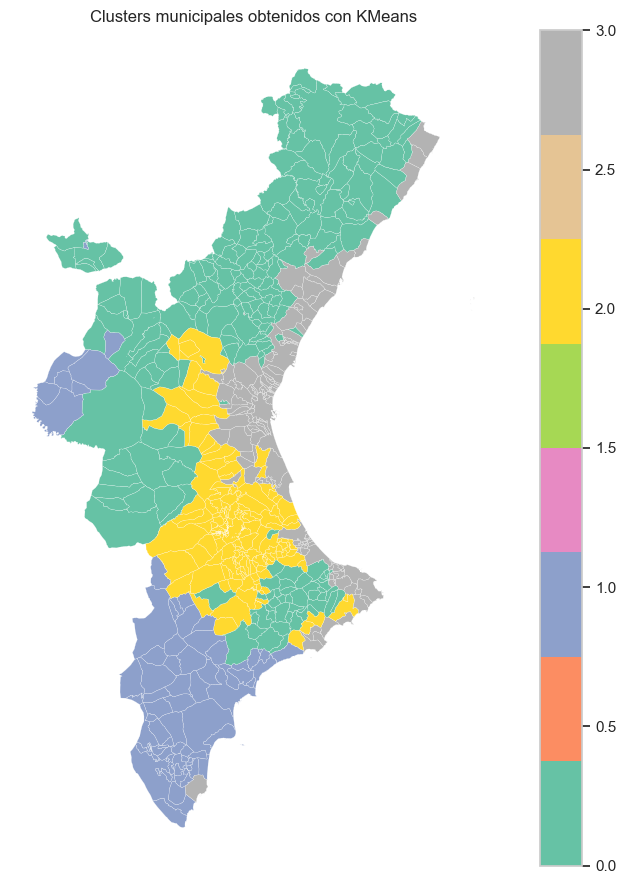

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_kmeans.plot(
    column="cluster_kmeans",
    cmap="Set2",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Clusters municipales obtenidos con KMeans")
ax.axis("off")
plt.tight_layout()
plt.show()


In [14]:
cluster_summary_features = model_features + [
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_fisica",
    "score_riesgo_exploratorio",
]
cluster_summary_features = [col for col in cluster_summary_features if col in df_mun.columns]

cluster_summary_agg = {"municipios": ("municipio", "count")}
cluster_summary_agg.update({col: (col, "mean") for col in cluster_summary_features})

cluster_summary = (
    df_mun.groupby("cluster_kmeans")
    .agg(**cluster_summary_agg)
    .round(2)
)

display(cluster_summary)

,municipios,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m,score_peligro_climatico_ampliado,score_vulnerabilidad,score_exposicion_fisica,score_riesgo_exploratorio
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,210,26.29,21.40,31.88,65.58,6.92,177.23,202.11,114.35,0.23,25.50,29.62,30111.11,25.71,23.49,0.36,640.44,0.31,0.44,0.00,0.29
1,68,19.35,10.50,34.26,182.79,7.02,654.43,278.94,60.60,0.20,431.05,23.33,29664.18,108.56,248.87,2.59,329.63,0.39,0.39,0.03,0.32
2,136,31.47,28.40,34.18,166.95,6.54,146.76,231.40,122.60,0.24,167.11,23.19,32162.73,77.76,94.25,1.73,306.90,0.44,0.37,0.02,0.33
3,128,27.17,21.95,32.41,82.02,7.50,133.82,202.56,114.05,0.26,2007.80,19.83,35138.91,328.49,1022.44,8.66,76.86,0.36,0.34,0.10,0.30


La representacion espacial permite valorar si los clusters identificados por `KMeans` presentan continuidad o concentracion territorial, algo especialmente importante en un problema geoespacial como el del presente TFG. Si los grupos muestran patrones espaciales recognoscibles, la segmentacion gana interpretabilidad y utilidad para fases posteriores de analisis y negocio.

Ademas, la tabla resumen por cluster facilita traducir cada grupo a un perfil territorial concreto, combinando intensidad climatica, vulnerabilidad demografica y contexto socioeconomico. Esta lectura resulta clave para pasar de una clasificacion puramente estadistica a una interpretacion aplicada del territorio.


## 7. Segundo modelo: Agglomerative Clustering

Como contraste frente a `KMeans`, se aplica un segundo enfoque de segmentacion no supervisada basado en `Agglomerative Clustering`. A diferencia de `KMeans`, este metodo no parte de centroides, sino de una logica jerarquica que va agrupando observaciones en funcion de su proximidad.

El objetivo de este segundo modelo no es reemplazar automaticamente al primero, sino comprobar si la estructura municipal detectada resulta estable bajo un enfoque alternativo y si los grupos obtenidos mantienen una interpretacion territorial razonable.


In [15]:
agg_model = AgglomerativeClustering(n_clusters=k_final)
df_mun["cluster_agg"] = agg_model.fit_predict(X_scaled)

print("Numero de clusters:", k_final)
print("Tamano de cada cluster:")
display(df_mun["cluster_agg"].value_counts().sort_index().to_frame("municipios"))

Numero de clusters: 4
Tamano de cada cluster:


,municipios
cluster_agg,
0,171
1,226
2,66
3,79


In [16]:
agg_labels = df_mun["cluster_agg"]

agg_metrics = pd.DataFrame(
    [
        {
            "modelo": "Agglomerative",
            "silhouette": silhouette_score(X_scaled, agg_labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, agg_labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, agg_labels),
        }
    ]
)

display(agg_metrics)


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,Agglomerative,0.204248,1.574267,121.644392


In [17]:
agg_profile = (
    df_mun.groupby("cluster_agg")[model_features]
    .mean()
    .round(2)
)

display(agg_profile)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_agg,,,,,,,,,,,,,,,,
0,32.50,30.15,33.40,131.24,7.00,202.77,226.84,129.69,0.24,317.62,23.88,32027.62,120.42,211.98,2.66,242.13
1,25.81,20.60,32.18,79.35,6.84,151.59,204.62,110.59,0.24,31.83,28.30,30440.89,26.83,27.17,0.44,626.24
2,19.53,10.68,34.21,180.74,6.99,671.44,279.39,60.71,0.20,463.14,23.12,29740.45,112.85,281.03,2.71,301.21
3,24.25,17.29,32.64,89.91,7.26,70.35,194.14,104.16,0.27,2814.14,18.88,36624.01,396.21,1324.19,10.94,71.76


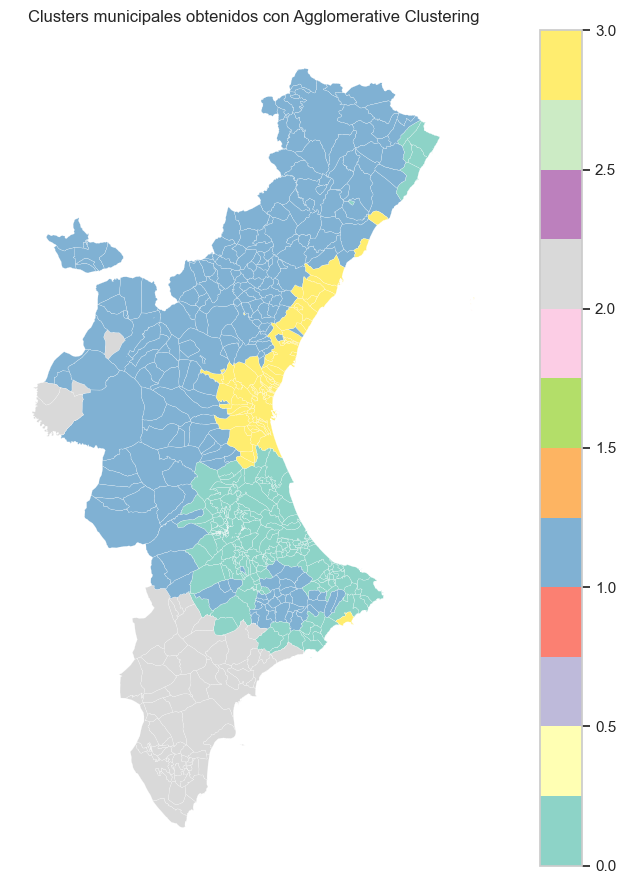

In [18]:
gdf_agg = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_agg"]],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_agg.plot(
    column="cluster_agg",
    cmap="Set3",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Clusters municipales obtenidos con Agglomerative Clustering")
ax.axis("off")
plt.tight_layout()
plt.show()

El segundo modelo permite comprobar si la segmentacion territorial observada con `KMeans` se mantiene bajo un enfoque jerarquico alternativo. La comparacion entre ambos resultados resulta util para evaluar la estabilidad de los patrones municipales detectados y para valorar que modelo ofrece una lectura mas interpretable del territorio.

En esta fase, el interes no reside unicamente en la calidad numerica de las metricas, sino tambien en la capacidad del modelo para generar grupos coherentes desde el punto de vista geografico, climatico y territorial, tanto en los perfiles medios como en su distribucion espacial.

## 8. Tercer enfoque exploratorio: DBSCAN espacial

Ademas de comparar `KMeans` con un modelo jerarquico, se incorpora una prueba exploratoria con `DBSCAN`. Este algoritmo resulta interesante para el TFG porque no obliga a fijar previamente el numero de grupos y permite detectar concentraciones espaciales densas, dejando como ruido aquellos municipios que no encajan claramente en ningun patron local.

En este caso no se utiliza como modelo principal de segmentacion, sino como contraste orientado a la deteccion de posibles zonas densas de riesgo. Para mantener una lectura territorial clara, se emplean la longitud, la latitud y el `score_riesgo_exploratorio`, todos ellos estandarizados antes del ajuste.

In [19]:
dbscan_features = ["lon", "lat", "score_riesgo_exploratorio"]
X_dbscan_raw = df_mun[dbscan_features].copy()
X_dbscan = StandardScaler().fit_transform(X_dbscan_raw)

dbscan_eps = 0.40
dbscan_min_samples = 5

dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=dbscan_min_samples)
df_mun["cluster_dbscan"] = dbscan_model.fit_predict(X_dbscan)

dbscan_counts = df_mun["cluster_dbscan"].value_counts().sort_index().to_frame("municipios")
n_dbscan_clusters = len(set(df_mun["cluster_dbscan"]) - {-1})
n_dbscan_noise = int((df_mun["cluster_dbscan"] == -1).sum())
dbscan_noise_pct = n_dbscan_noise / len(df_mun) * 100

print("Parametros DBSCAN:", {"eps": dbscan_eps, "min_samples": dbscan_min_samples})
print("Clusters densos detectados:", n_dbscan_clusters)
print(f"Municipios clasificados como ruido: {n_dbscan_noise} ({dbscan_noise_pct:.1f}%)")
display(dbscan_counts)

Parametros DBSCAN: {'eps': 0.4, 'min_samples': 5}
Clusters densos detectados: 4
Municipios clasificados como ruido: 50 (9.2%)


,municipios
cluster_dbscan,
-1,50
0,271
1,176
2,39
3,6


In [20]:
dbscan_core_mask = df_mun["cluster_dbscan"] != -1

if n_dbscan_clusters >= 2 and dbscan_core_mask.sum() > n_dbscan_clusters:
    X_dbscan_core = X_dbscan[dbscan_core_mask]
    dbscan_labels_core = df_mun.loc[dbscan_core_mask, "cluster_dbscan"]
    dbscan_metrics = pd.DataFrame(
        [
            {
                "modelo": "DBSCAN (core)",
                "silhouette": silhouette_score(X_dbscan_core, dbscan_labels_core),
                "davies_bouldin": davies_bouldin_score(X_dbscan_core, dbscan_labels_core),
                "calinski_harabasz": calinski_harabasz_score(X_dbscan_core, dbscan_labels_core),
                "clusters": n_dbscan_clusters,
                "ruido_pct": dbscan_noise_pct,
            }
        ]
    )
else:
    dbscan_metrics = pd.DataFrame(
        [
            {
                "modelo": "DBSCAN (core)",
                "silhouette": np.nan,
                "davies_bouldin": np.nan,
                "calinski_harabasz": np.nan,
                "clusters": n_dbscan_clusters,
                "ruido_pct": dbscan_noise_pct,
            }
        ]
    )

display(dbscan_metrics)

dbscan_profile_cols = [
    "score_riesgo_exploratorio",
    "score_peligro_climatico_ampliado",
    "score_vulnerabilidad",
    "score_exposicion_fisica",
    "lon",
    "lat",
]

dbscan_profile = (
    df_mun.groupby("cluster_dbscan")[dbscan_profile_cols]
    .agg(["count", "mean"])
    .round(3)
)

display(dbscan_profile)

,modelo,silhouette,davies_bouldin,calinski_harabasz,clusters,ruido_pct
0,DBSCAN (core),0.338182,0.823919,219.984337,4,9.225092


score_riesgo_exploratorio         \
                                   count   mean   
cluster_dbscan                                    
-1                                    50  0.331   
 0                                   271  0.332   
 1                                   176  0.260   
 2                                    39  0.310   
 3                                     6  0.246   

               score_peligro_climatico_ampliado        score_vulnerabilidad  \
                                          count   mean                count   
cluster_dbscan                                                                
-1                                           50  0.347                   50   
 0                                          271  0.422                  271   
 1                                          176  0.286                  176   
 2                                           39  0.361                   39   
 3                                            6  0.259                    6   

                      score_exposicion_fisica          lon          lat  \
                 mean                   count   mean count   mean count   
cluster_dbscan                                                            
-1              0.470                      50  0.082    50 -0.836    50   
 0              0.386                     271  0.026   271 -0.438   271   
 1              0.368                     176  0.031   176 -0.452   176   
 2              0.428                      39  0.004    39  0.046    39   
 3              0.377                       6  0.017     6  0.067     6   

                        
                  mean  
cluster_dbscan          
-1              39.588  
 0              38.780  
 1              39.757  
 2              40.492  
 3              40.167

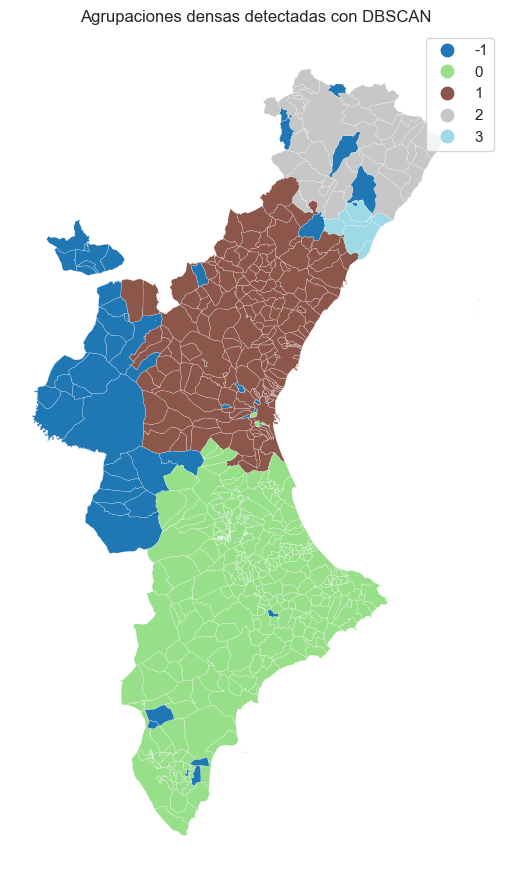

In [21]:
gdf_dbscan = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_dbscan", "score_riesgo_exploratorio"]],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_dbscan.plot(
    column="cluster_dbscan",
    cmap="tab20",
    categorical=True,
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Agrupaciones densas detectadas con DBSCAN")
ax.axis("off")
plt.tight_layout()
plt.show()

La lectura de `DBSCAN` debe hacerse con prudencia. El algoritmo aporta valor porque permite identificar concentraciones espaciales de municipios con una combinacion parecida de localizacion y riesgo exploratorio, y tambien senala municipios que no forman parte de ningun nucleo denso.

Sin embargo, el resultado depende de los parametros `eps` y `min_samples`, y sus metricas se calculan solo sobre los puntos no clasificados como ruido. Por ello, se mantiene como contraste exploratorio de hotspots y no sustituye a `KMeans` como segmentacion principal del TFG.

## 9. Comparacion entre modelos y seleccion del enfoque mas util

Una vez aplicados `KMeans` y `Agglomerative Clustering`, el siguiente paso consiste en comparar ambos enfoques tanto desde el punto de vista cuantitativo como interpretativo. Para ello, se utilizan las metricas de adecuacion disponibles y se contrastan tambien la distribucion de municipios por cluster y la coherencia territorial de los grupos obtenidos.

El objetivo no es identificar un modelo matematicamente perfecto, sino seleccionar el enfoque que ofrezca un mejor equilibrio entre consistencia interna, estabilidad e interpretabilidad para el problema del TFG.


In [22]:
kmeans_labels = df_mun["cluster_kmeans"]

kmeans_metrics = pd.DataFrame(
    [
        {
            "modelo": "KMeans",
            "silhouette": silhouette_score(X_scaled, kmeans_labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
            "clusters": k_final,
            "ruido_pct": 0.0,
        }
    ]
)

model_comparison = pd.concat([kmeans_metrics, agg_metrics, dbscan_metrics], ignore_index=True, sort=False)
display(model_comparison)

,modelo,silhouette,davies_bouldin,calinski_harabasz,clusters,ruido_pct
0,KMeans,0.215062,1.465831,139.201311,4.0,0.000000
1,Agglomerative,0.204248,1.574267,121.644392,NaN,NaN
2,DBSCAN (core),0.338182,0.823919,219.984337,4.0,9.225092


In [23]:
cluster_sizes = pd.concat(
    {
        "KMeans": df_mun["cluster_kmeans"].value_counts().sort_index(),
        "Agglomerative": df_mun["cluster_agg"].value_counts().sort_index(),
        "DBSCAN": df_mun["cluster_dbscan"].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)

display(cluster_sizes)

,KMeans,Agglomerative,DBSCAN
0,210,171,271
1,68,226,176
2,136,66,39
3,128,79,6
-1,0,0,50


In [24]:
print("Perfil medio de KMeans")
display(cluster_profile)
print("Perfil medio de Agglomerative")
display(agg_profile)
print("Perfil medio de DBSCAN")
display(dbscan_profile)

Perfil medio de KMeans


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_kmeans,,,,,,,,,,,,,,,,
0,26.29,21.40,31.88,65.58,6.92,177.23,202.11,114.35,0.23,25.50,29.62,30111.11,25.71,23.49,0.36,640.44
1,19.35,10.50,34.26,182.79,7.02,654.43,278.94,60.60,0.20,431.05,23.33,29664.18,108.56,248.87,2.59,329.63
2,31.47,28.40,34.18,166.95,6.54,146.76,231.40,122.60,0.24,167.11,23.19,32162.73,77.76,94.25,1.73,306.90
3,27.17,21.95,32.41,82.02,7.50,133.82,202.56,114.05,0.26,2007.80,19.83,35138.91,328.49,1022.44,8.66,76.86


Perfil medio de Agglomerative


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,dias_suelo_seco,dias_radiacion_alta,dias_runoff_extremo,humedad_suelo_media_periodo,densidad_poblacion,mayores_65_pct,renta_media_hogar,densidad_edificios_km2,densidad_viviendas_catastro_km2,ratio_huella_edificada_pct,altitud_m
cluster_agg,,,,,,,,,,,,,,,,
0,32.50,30.15,33.40,131.24,7.00,202.77,226.84,129.69,0.24,317.62,23.88,32027.62,120.42,211.98,2.66,242.13
1,25.81,20.60,32.18,79.35,6.84,151.59,204.62,110.59,0.24,31.83,28.30,30440.89,26.83,27.17,0.44,626.24
2,19.53,10.68,34.21,180.74,6.99,671.44,279.39,60.71,0.20,463.14,23.12,29740.45,112.85,281.03,2.71,301.21
3,24.25,17.29,32.64,89.91,7.26,70.35,194.14,104.16,0.27,2814.14,18.88,36624.01,396.21,1324.19,10.94,71.76


Perfil medio de DBSCAN


score_riesgo_exploratorio         \
                                   count   mean   
cluster_dbscan                                    
-1                                    50  0.331   
 0                                   271  0.332   
 1                                   176  0.260   
 2                                    39  0.310   
 3                                     6  0.246   

               score_peligro_climatico_ampliado        score_vulnerabilidad  \
                                          count   mean                count   
cluster_dbscan                                                                
-1                                           50  0.347                   50   
 0                                          271  0.422                  271   
 1                                          176  0.286                  176   
 2                                           39  0.361                   39   
 3                                            6  0.259                    6   

                      score_exposicion_fisica          lon          lat  \
                 mean                   count   mean count   mean count   
cluster_dbscan                                                            
-1              0.470                      50  0.082    50 -0.836    50   
 0              0.386                     271  0.026   271 -0.438   271   
 1              0.368                     176  0.031   176 -0.452   176   
 2              0.428                      39  0.004    39  0.046    39   
 3              0.377                       6  0.017     6  0.067     6   

                        
                  mean  
cluster_dbscan          
-1              39.588  
 0              38.780  
 1              39.757  
 2              40.492  
 3              40.167

La comparacion entre modelos debe interpretarse de forma conjunta. Las metricas cuantitativas permiten valorar la calidad interna de la segmentacion, pero no bastan por si solas para decidir el mejor enfoque. En un problema como este, tambien resulta clave la interpretabilidad de los clusters, su equilibrio en tamano y la coherencia territorial observada en los mapas.

En los resultados obtenidos, `KMeans` se considera el enfoque mas util para el TFG en esta fase porque ofrece una solucion estable, equilibrada y facil de explicar a partir de los perfiles medios de cada cluster. `Agglomerative Clustering` funciona como contraste metodologico y ayuda a comprobar que la estructura territorial no depende exclusivamente de un unico algoritmo. `DBSCAN` aporta una lectura complementaria de densidad espacial y posibles hotspots, aunque no se selecciona como modelo principal por su sensibilidad parametrica y por la existencia de municipios clasificados como ruido.

In [25]:
print("Resumen final de metricas:")
display(model_comparison)

selected_model = "KMeans"
print("Modelo seleccionado para el analisis posterior:", selected_model)
print("Justificacion: solucion equilibrada, interpretable y coherente con la lectura territorial del TFG.")
print("DBSCAN se conserva como contraste exploratorio para detectar agrupaciones densas y municipios singulares.")

Resumen final de metricas:


,modelo,silhouette,davies_bouldin,calinski_harabasz,clusters,ruido_pct
0,KMeans,0.215062,1.465831,139.201311,4.0,0.000000
1,Agglomerative,0.204248,1.574267,121.644392,NaN,NaN
2,DBSCAN (core),0.338182,0.823919,219.984337,4.0,9.225092


Modelo seleccionado para el analisis posterior: KMeans
Justificacion: solucion equilibrada, interpretable y coherente con la lectura territorial del TFG.
DBSCAN se conserva como contraste exploratorio para detectar agrupaciones densas y municipios singulares.


## 10. Exportacion de la base municipal segmentada

Como salida del proceso de modelado, se guarda una version de la tabla municipal analitica enriquecida con las etiquetas de cluster generadas por `KMeans` y `Agglomerative Clustering`. Este fichero facilita la continuidad hacia el siguiente cuaderno, ya que permite reutilizar directamente la segmentacion obtenida sin necesidad de recalcular los modelos.

La base exportada conserva los indicadores climaticos, territoriales, sociales y de Catastro del `Notebook 3`, incorpora la proyeccion `PCA` de diagnostico y anade las variables `cluster_kmeans` y `cluster_agg`, utiles para comparacion, representacion y lectura orientada a negocio.

In [26]:
df_mun.to_csv(SEGMENTED_MUNICIPAL_FILE, index=False)

print("Base municipal segmentada guardada en:", SEGMENTED_MUNICIPAL_FILE)
print("Shape:", df_mun.shape)
print("Columnas:", len(df_mun.columns))
print("Duplicados municipales:", df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum())
print("Municipios sin cluster KMeans:", df_mun["cluster_kmeans"].isna().sum())
print("Municipios sin cluster Agglomerative:", df_mun["cluster_agg"].isna().sum())
print("Municipios sin etiqueta DBSCAN:", df_mun["cluster_dbscan"].isna().sum())
print("Municipios marcados como ruido por DBSCAN:", (df_mun["cluster_dbscan"] == -1).sum())

assert SEGMENTED_MUNICIPAL_FILE.exists(), "No se ha generado la salida segmentada."
assert len(df_mun) == 542, "La salida segmentada debe tener una fila por municipio."
assert df_mun.duplicated(subset=["municipio", "CODNUT2", "CODNUT3"]).sum() == 0, "La salida segmentada contiene duplicados."
assert df_mun["cluster_kmeans"].isna().sum() == 0, "Hay municipios sin cluster KMeans."
assert df_mun["cluster_agg"].isna().sum() == 0, "Hay municipios sin cluster Agglomerative."
assert df_mun["cluster_dbscan"].isna().sum() == 0, "Hay municipios sin etiqueta DBSCAN."

display(df_mun[["municipio", "cluster_kmeans", "cluster_agg", "cluster_dbscan", "score_riesgo_exploratorio"]].head())

Base municipal segmentada guardada en: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv
Shape: (542, 85)
Columnas: 85
Duplicados municipales: 0
Municipios sin cluster KMeans: 0
Municipios sin cluster Agglomerative: 0
Municipios sin etiqueta DBSCAN: 0
Municipios marcados como ruido por DBSCAN: 50


,municipio,cluster_kmeans,cluster_agg,cluster_dbscan,score_riesgo_exploratorio
0,Ademuz,0,1,-1,0.244267
1,Ador,2,0,0,0.366637
2,Agost,1,2,0,0.302003
3,Agres,2,1,0,0.311068
4,Agullent,2,0,0,0.313503


## 11. Conclusiones del modelado y continuidad hacia Analisis de Negocio

La fase de modelado desarrollada en este cuaderno permite comprobar que el dataset municipal construido en las fases anteriores no solo es util para el analisis descriptivo, sino tambien para la identificacion de patrones territoriales mediante tecnicas de segmentacion no supervisada. La aplicacion de distintos modelos y su comparacion posterior permiten avanzar desde una lectura exploratoria del territorio hacia una clasificacion mas estructurada de perfiles municipales.

La segmentacion actual aprovecha ya las mejoras incorporadas en la fase anterior: variables climaticas extendidas de `ERA5-Land`, indicadores de exposicion edificada de Catastro y variables sociales y economicas del INE. Esto permite que los clusters no dependan solo de precipitacion, temperatura y viento, sino tambien de dimensiones fisicas y territoriales relevantes para un problema de riesgo asegurador.

Los resultados obtenidos deben interpretarse con cautela, ya que los clusters construidos no representan categorias absolutas ni equivalen directamente a niveles reales de siniestralidad. No obstante, si resultan utiles para detectar combinaciones recurrentes de intensidad climatica, exposicion y vulnerabilidad territorial, lo que aporta valor analitico al TFG incluso en ausencia de datos internos de siniestros.

En esta fase, `KMeans` se selecciona como enfoque principal por ofrecer una solucion equilibrada e interpretable. A partir de esta base segmentada, la siguiente fase del proyecto consistira en traducir los hallazgos del modelado a una interpretacion orientada a negocio.

Esto implica valorar que perfiles municipales resultan mas relevantes desde la perspectiva aseguradora, que implicaciones pueden tener para tarificacion, prevencion o gestion territorial de la cartera, y que limitaciones deben tenerse presentes antes de extraer conclusiones aplicadas.